# Attentional Spatial Bias: Analysis

Ported from `attentional_spatial_bias_colab.py`, which someone else wrote
and which hadn't been verified before this notebook. Checking its logic
against `data/raw/` turned up two real bugs, see the note before each fix.

**Data:** 12 subjects with the full 48-trial, 6-arrangement design:
8 LTR (43, 51, 101, 102, 104, 105, 106, 107) and 4 RTL (44, 52, 54, 103).
subject-1/3/50/83 are older pilot runs with an incompatible position
scheme, so they're left out.

**Caveat:** subjects 43 and 44 were recorded before the experiment
script's "FIX (V8)" HiDPI fix, so their online-logged `first_fix_side` is
unusable (see Section 6). Their FPOG-recomputed values are fine and a
sensitivity check excluding them barely moves the group estimates.

## 1. Setup

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data location

Restricted to the 12 subjects with the full 48-trial, 6-arrangement design.

In [2]:
DATA_DIR = "../data/raw"
SUBJECTS = ["subject-43", "subject-44", "subject-51", "subject-52", "subject-54", "subject-60", "subject-62", "subject-63", "subject-64", "subject-65", "subject-66", "subject-101", "subject-102", "subject-103", "subject-104", "subject-105", "subject-106" , "subject-109" , "subject-110"]
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

for s in SUBJECTS:
    for ext in (".csv", ".tsv"):
        p = os.path.join(DATA_DIR, s + ext)
        assert os.path.exists(p), f"missing {p}"
print("Data files found for:", SUBJECTS)

Data files found for: ['subject-43', 'subject-44', 'subject-51', 'subject-52', 'subject-54', 'subject-60', 'subject-62', 'subject-63', 'subject-64', 'subject-65', 'subject-66', 'subject-101', 'subject-102', 'subject-103', 'subject-104', 'subject-105', 'subject-106', 'subject-109', 'subject-110']


## 3. Config: arrangement / clock mapping

**Bug 1:** the original code derived clock hour from pixel offsets with
`atan2(y, x)`, which assumes math convention (y up). The logged offsets
are actually screen convention (y down), confirmed against
`scripts/data_evaluation.ipynb` and against real scanpaths. Feeding y-down
data into a y-up formula mirrors every non-horizontal arrangement
top-to-bottom: position `4` is really `(12, 6)`, not `(6, 12)` like the
original code had it, and 2/3/5/6 are off the same way. Fixed by computing
the clock hour straight from the pixel offsets instead of a hand-written
lookup table, so there's nothing left to drift out of sync.

**Design issue, not a bug:** the six arrangements are the six diameters of
a clock face. `img_left`/`img_right` always means "7 to 12 o'clock side"
vs "1 to 6 o'clock side," not screen left/right. For arrangement `(12, 6)`
both images sit on the vertical meridian, so calling `img_right` "the right
stimulus" there is really "the bottom stimulus." Fixed by recording the
actual fixated clock hour (Section 4) and deriving left/right and up/down
from it afterward (Section 8), each skipping the arrangement where that
axis doesn't apply.

In [3]:
POSITION_LABELS = {
    "1": (9, 3), "2": (10, 4), "3": (11, 5),
    "4": (12, 6), "5": (7, 1), "6": (8, 2),
}
ARRANGEMENT_ORDER = [(7, 1), (8, 2), (9, 3), (10, 4), (11, 5), (12, 6)]
CLOCK_ORDER = list(range(1, 13))

MIN_LATENCY_MS = 80   # saccades planned before stimulus onset land faster than this
WINSOR_PROP = 0.2
N_BOOT = 5000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


def clock_hour_from_xy(x, y):
    # clock hour for a point at screen offset (x, y) from center, y-down
    angle = math.degrees(math.atan2(y, x))
    h = (round(angle / 30.0) + 3) % 12
    return 12 if h == 0 else h


def clock_for_side(arrangement, side):
    return arrangement[0] if side == "left" else arrangement[1]


def hour_side(hour):
    # physical screen left/right of a clock hour; 6 and 12 sit on the
    # vertical meridian (x=0) and have no left/right meaning
    if pd.isna(hour):
        return np.nan
    if hour in (6, 12):
        return np.nan
    return "left" if hour in (7, 8, 9, 10, 11) else "right"


def hour_vert(hour):
    # physical screen up/down of a clock hour; 3 and 9 sit on the
    # horizontal meridian (y=0) and have no up/down meaning
    if pd.isna(hour):
        return np.nan
    if hour in (3, 9):
        return np.nan
    return "up" if hour in (10, 11, 12, 1, 2) else "down"

In [4]:
# Sanity-check POSITION_LABELS against the actual logged pixel offsets
seen = {}
for s in SUBJECTS:
    df = pd.read_csv(os.path.join(DATA_DIR, s + ".csv"), dtype=str)
    for _, row in df.iterrows():
        pos = row["position"]
        if pos not in seen:
            seen[pos] = (float(row["x_left"]), float(row["y_left"]),
                         float(row["x_right"]), float(row["y_right"]))

print(f"{'position':>8} {'computed':>10} {'expected':>10}  status")
for pos in sorted(seen, key=int):
    xl, yl, xr, yr = seen[pos]
    computed = (clock_hour_from_xy(xl, yl), clock_hour_from_xy(xr, yr))
    expected = POSITION_LABELS[pos]
    status = "OK" if computed == expected else "MISMATCH"
    print(f"{pos:>8} {str(computed):>10} {str(expected):>10}  {status}")

position   computed   expected  status
       1     (9, 3)     (9, 3)  OK
       2    (10, 4)    (10, 4)  OK
       3    (11, 5)    (11, 5)  OK
       4    (12, 6)    (12, 6)  OK
       5     (7, 1)     (7, 1)  OK
       6     (8, 2)     (8, 2)  OK


## 4. Load + tidy the subject CSVs

`block_index` is what filters out the pilot files. It's required here and
missing there, since their `position` codes mean something different
anyway.

`fix_direction()` also accepts a literal `"LEFT"`/`"RIGHT"`/`"none"`
encoding seen in one of the pilot files, even though the current subjects
only use the filename form.

In [5]:
def load_subject_csv(path):
    df = pd.read_csv(path, dtype=str)
    keep_cols = [
        "subject_nr", "group", "lang", "trial_nr", "block_index",
        "position", "img_left", "img_right",
        "x_left", "y_left", "x_right", "y_right",
        "first_fix_side", "first_fix_rt", "response_time", "correct",
    ]
    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path}: missing expected columns {missing}")
    df = df[keep_cols].copy()

    df["trial_nr"] = df["trial_nr"].astype(int)
    df["block_index"] = df["block_index"].astype(int)
    for c in ["first_fix_rt", "response_time", "x_left", "y_left", "x_right", "y_right"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["arrangement"] = df["position"].map(POSITION_LABELS)
    if df["arrangement"].isna().any():
        bad = df.loc[df["arrangement"].isna(), "position"].unique()
        raise ValueError(f"{path}: unmapped position code(s) {bad} -- update POSITION_LABELS")

    def fix_direction(row):
        side = row["first_fix_side"]
        if pd.isna(side) or side == "none":
            return "none"
        if side == row["img_left"]:
            return "left"
        if side == row["img_right"]:
            return "right"
        su = str(side).strip().upper()
        if su in ("LEFT", "RIGHT"):
            return su.lower()
        return "none"

    df["first_fix_direction"] = df.apply(fix_direction, axis=1)
    # NOTE: these three are derived from the buggy CSV-log `first_fix_side`
    # (see Section 6/7 -- unusable for subjects 43/44). Named with a
    # `csvlog_` prefix so nothing downstream mistakes them for the
    # FPOG-based (correct) versions computed in Section 7.
    df["csvlog_fixated_clock"] = df.apply(
        lambda r: clock_for_side(r["arrangement"], r["first_fix_direction"])
        if r["first_fix_direction"] != "none" else np.nan, axis=1)
    df["csvlog_physical_side"] = df["csvlog_fixated_clock"].map(hour_side)
    df["csvlog_physical_vert"] = df["csvlog_fixated_clock"].map(hour_vert)

    reading_start_side = {"LTR": "left", "RTL": "right"}
    df["reading_start_side"] = df["group"].map(reading_start_side)
    df["fix_matches_reading_onset"] = (
        df["first_fix_direction"] == df["reading_start_side"]
    ).where(df["first_fix_direction"] != "none")

    df.rename(columns={"first_fix_rt": "first_fix_rt_ms",
                        "response_time": "response_time_ms"}, inplace=True)
    df["subject_nr"] = df["subject_nr"].astype(str)
    return df


def apply_exclusions(df, side_col="first_fix_direction", rt_col="first_fix_rt_ms",
                      rt_cutoff_ms=None, min_latency_ms=None,
                      reason_col="exclusion_reason", excluded_col="excluded"):
    # rt_cutoff_ms=None means no upper latency cutoff, the current default:
    # slow first fixations cluster in arrangements without an upper-left
    # stimulus, so cutting them would be behaviorally selective (see the
    # latency-by-arrangement section). min_latency_ms=None keeps the original
    # script's behaviour (no lower bound); the FPOG-based pass sets it to
    # MIN_LATENCY_MS to drop anticipatory first fixations.
    df = df.copy()
    df[reason_col] = "none"
    no_fix = df[side_col] == "none"
    df.loc[no_fix, reason_col] = "no_first_fixation_registered"
    if rt_cutoff_ms is not None:
        too_slow = (~no_fix) & (df[rt_col] > rt_cutoff_ms)
        df.loc[too_slow, reason_col] = "first_fix_rt_over_cutoff"
    if min_latency_ms is not None:
        too_fast = (~no_fix) & (df[rt_col] < min_latency_ms)
        df.loc[too_fast, reason_col] = "first_fix_anticipatory"
    df[excluded_col] = df[reason_col] != "none"
    return df


paths = [os.path.join(DATA_DIR, s + ".csv") for s in SUBJECTS]
frames = [load_subject_csv(p) for p in paths]
trials = pd.concat(frames, ignore_index=True)
# Not exported yet -- the FPOG-based columns (Sections 6-7) still need to be
# merged in before `trials_combined.csv` is written (see Section 7).

n_subj = trials["subject_nr"].nunique()
print(f"Loaded {len(paths)} file(s), {n_subj} subject(s), {len(trials)} trials.")

Loaded 19 file(s), 19 subject(s), 912 trials.


## 5. Bootstrap helpers

`hierarchical_bootstrap_ci` resamples subjects first, then trials within
each resampled subject, since trials from the same subject aren't
independent. Point estimate is the mean of subject means. This shouldn't
need any changes once more subjects are added.

In [6]:
def hierarchical_bootstrap_ci(arrays, n_boot=N_BOOT):
    # arrays: one 0/1 (or numeric) array per subject.
    # Stage 1 resamples subjects, stage 2 resamples trials within each
    # sampled subject. Point estimate = unweighted mean of subject means.
    arrays = [np.asarray(a, dtype=float) for a in arrays if len(a) > 0]
    k = len(arrays)
    if k == 0:
        return np.nan, np.nan, np.nan
    point = float(np.mean([a.mean() for a in arrays]))
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, k, k) if k > 1 else np.zeros(1, dtype=int)
        boots[i] = np.mean([arrays[j][rng.integers(0, len(arrays[j]), len(arrays[j]))].mean()
                            for j in idx])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


colors = {"LTR": "#1f77b4", "RTL": "#d62728"}

## 6. Verifying `first_fix_side` against the raw eye-tracker samples

`first_fix_side` isn't a raw measurement. It's a value the OpenSesame
script computed live and logged. This section recomputes it independently
from the tracker's own fixation stream.

`FPOGX`/`FPOGY` are GazePoint's fixation-classified gaze coordinates
(grouped by `FPOGID`, with `FPOGS`/`FPOGD` for start time and duration),
not raw per-sample gaze. The `.tsv` also has `STIMULUS_ONSET`/`IMAGE_OFFSET`
markers to segment trials.

For each trial: take the fixations inside that window, in time order, and
find the first one landing inside either stimulus's AOI. That's a square,
half-width 150 px, matching the margin the experiment itself uses online
(stimuli are about 256x256 px on screen, centers 616 px apart, so the two
AOIs never overlap). Fixations already running at stimulus onset get
dropped, since they belong to the preceding central fixation dot rather
than the stimuli. Only fixations starting at or after onset count.

In [7]:
SCREEN_W, SCREEN_H = 1920, 1080
# Square AOI half-width around each stimulus center, taken from the
# experiment script's own online detection (margin = 150 in
# V7_AttentionalSpatialBias_.osexp). Stimuli are ~256x256 px on screen
# (1025x1025 png at scale=0.25), so this is half-size 128 px + ~22 px slack.
AOI_MARGIN_PX = 150


def compute_fpog_first_fixation(subj, sub_trials):
    # sub_trials: this subject's rows from `trials` (already parsed by
    # load_subject_csv), used for the per-trial stimulus coordinates --
    # avoids re-reading and re-parsing the CSV with separate logic.
    tsv_path = os.path.join(DATA_DIR, subj + ".tsv")

    tsv = pd.read_csv(tsv_path, sep="\t")
    tsv.replace(["NA", "undefined"], np.nan, inplace=True)
    for c in ["TIME", "FPOGX", "FPOGY", "FPOGV", "FPOGID", "FPOGS"]:
        tsv[c] = pd.to_numeric(tsv[c], errors="coerce")
    tsv = tsv.dropna(subset=["FPOGX", "FPOGY", "FPOGID"]).sort_values("TIME").reset_index(drop=True)

    onsets = tsv[tsv["USER"].notna() & tsv["USER"].astype(str).str.contains("STIMULUS_ONSET", na=False)].copy()
    offsets = tsv[tsv["USER"].notna() & tsv["USER"].astype(str).str.contains("IMAGE_OFFSET", na=False)]["TIME"].values

    sub_trials = sub_trials.sort_values("trial_nr").reset_index(drop=True)
    if len(onsets) != len(sub_trials):
        raise ValueError(f"{subj}: {len(onsets)} STIMULUS_ONSET markers vs {len(sub_trials)} trial rows")

    rows = []
    for (_, onset_row), (_, trial) in zip(onsets.iterrows(), sub_trials.iterrows()):
        t0 = onset_row["TIME"]
        later = offsets[offsets > t0]
        t_end = later[0] if len(later) else t0 + 10.0

        window = tsv[(tsv["TIME"] >= t0) & (tsv["TIME"] <= t_end) & (tsv["FPOGV"] == 1) &
                     tsv["FPOGX"].between(0, 1) & tsv["FPOGY"].between(0, 1)]

        fixations = (window.groupby("FPOGID")
                     .agg(dx=("FPOGX", "mean"), dy=("FPOGY", "mean"), FPOGS=("FPOGS", "min"))
                     .sort_values("FPOGS"))
        # the fixation in progress at stimulus onset is the tail of the
        # central-dot fixation, not a response to the stimuli -- drop it
        fixations = fixations[fixations["FPOGS"] >= t0]

        lx = SCREEN_W / 2 + trial["x_left"]
        ly = SCREEN_H / 2 + trial["y_left"]
        rx = SCREEN_W / 2 + trial["x_right"]
        ry = SCREEN_H / 2 + trial["y_right"]

        side, rt_ms = "none", np.nan
        for _, fx in fixations.iterrows():
            xi, yi = fx["dx"] * SCREEN_W, fx["dy"] * SCREEN_H
            in_left = abs(xi - lx) < AOI_MARGIN_PX and abs(yi - ly) < AOI_MARGIN_PX
            in_right = abs(xi - rx) < AOI_MARGIN_PX and abs(yi - ry) < AOI_MARGIN_PX
            if in_left or in_right:  # AOIs are 616 px apart, never both
                side = "left" if in_left else "right"
                rt_ms = (fx["FPOGS"] - t0) * 1000.0  # s -> ms, same units as first_fix_rt
                break

        rows.append(dict(subject_nr=str(trial["subject_nr"]), trial_nr=int(trial["trial_nr"]),
                          fpog_first_fix_direction=side, fpog_first_fix_rt_ms=rt_ms))
    return pd.DataFrame(rows)


subj_id = {s: s.split("-")[1] for s in SUBJECTS}  # "subject-43" -> "43"
fpog_frames = [compute_fpog_first_fixation(s, trials[trials["subject_nr"] == subj_id[s]])
               for s in SUBJECTS]
fpog_df = pd.concat(fpog_frames, ignore_index=True)

# drop any fpog_* columns from a previous run of this cell, so re-running it
# doesn't create _x/_y merge collisions
trials = trials.drop(columns=[c for c in trials.columns if c.startswith("fpog_")])
trials = trials.merge(fpog_df, on=["subject_nr", "trial_nr"], validate="one_to_one")
# Still not exported -- Section 7 adds the FPOG-based exclusion flags and
# fixated_clock/physical_side/physical_vert columns, then writes
# `trials_combined.csv` once, with everything in it.

print("=== CSV-logged first_fix_direction vs. FPOG-recomputed first_fix_direction ===")
print(pd.crosstab(trials["first_fix_direction"], trials["fpog_first_fix_direction"],
                   rownames=["CSV first_fix_side"], colnames=["FPOG-recomputed"]))
agree = (trials["first_fix_direction"] == trials["fpog_first_fix_direction"]).mean()
print(f"\nAgreement: {agree:.1%}")
print("\nCSV first_fix_side value counts:", trials["first_fix_direction"].value_counts().to_dict())
print("FPOG-recomputed value counts:   ", trials["fpog_first_fix_direction"].value_counts().to_dict())

=== CSV-logged first_fix_direction vs. FPOG-recomputed first_fix_direction ===
FPOG-recomputed     left  none  right
CSV first_fix_side                   
left                 537     0     26
none                  18     4     12
right                 37     0    278

Agreement: 89.8%

CSV first_fix_side value counts: {'left': 563, 'right': 315, 'none': 34}
FPOG-recomputed value counts:    {'left': 592, 'right': 316, 'none': 4}


For subjects 43/44, `first_fix_side` never reports a rightward fixation
(0/96 trials), while the FPOG recomputation finds plenty in both. That's
not noise, it's a systematic left/none bias. The experiment script has a
fix for exactly this failure mode ("FIX (V8): use var.width/var.height, not
win.size," a HiDPI coordinate bug), so 43/44 were most likely recorded
before that fix went in and 51 after. From here on the notebook uses the
FPOG-recomputed values.

## 7. Exclusions on the FPOG-recomputed first fixation

Only two exclusions: trials with no FPOG-detected AOI fixation, and
anticipatory first fixations (latency < 80 ms, planned before stimulus
onset). There is no upper latency cutoff: slow first fixations aren't
random, they cluster in arrangements that offer no upper-left stimulus
(see the latency-by-arrangement section below), so cutting them would be
behaviorally selective. The group bias estimates barely change either way.
Produces `df_valid_fpog`, used for everything from here on.

This cell also writes `results/trials_combined.csv`, the one export of the
full per-trial table. It contains **both** versions of
fixated_clock/physical_side/physical_vert, prefixed so their provenance is
unambiguous:

- **`fpog_fixated_clock` / `fpog_physical_side` / `fpog_physical_vert`** --
  recomputed offline from the tracker's fixation stream (Section 6), with
  the Section 7 exclusions applied (`NaN` for excluded trials or trials with
  no FPOG-detected fixation). **Use these.** They're what every analysis
  from here on in this notebook uses.
- `csvlog_fixated_clock` / `csvlog_physical_side` / `csvlog_physical_vert`
  -- derived from the online-logged `first_fix_side`, which is known to be
  buggy for subjects 43/44 (Section 6: 0/96 rightward fixations logged,
  not real behavior). Kept only so the CSV-log-vs-FPOG comparison in
  Section 6 is reproducible from the exported file; don't use these for
  any actual analysis.

In [8]:
trials = apply_exclusions(trials, side_col="fpog_first_fix_direction",
                           rt_col="fpog_first_fix_rt_ms",
                           min_latency_ms=MIN_LATENCY_MS,
                           reason_col="fpog_exclusion_reason", excluded_col="fpog_excluded")

n_excl_fpog = trials["fpog_excluded"].sum()
print(f"FPOG-based: excluded {n_excl_fpog}/{len(trials)} trials "
      f"({n_excl_fpog/len(trials):.1%}).")
print("\nExclusion breakdown:")
print(trials["fpog_exclusion_reason"].value_counts().to_string())
print(f"\n(no AOI fixation / latency < {MIN_LATENCY_MS} ms anticipatory; "
      f"no upper latency cutoff, slow first fixations are analyzed below)")

# FPOG-based fixated_clock/physical_side/physical_vert, computed for every
# trial (not just the surviving ones) so they can be exported alongside the
# CSV-log versions below -- NaN wherever fpog_excluded is True or
# fpog_first_fix_direction is "none", exactly like df_valid_fpog gets it.
trials["fpog_fixated_clock"] = trials.apply(
    lambda r: clock_for_side(r["arrangement"], r["fpog_first_fix_direction"])
    if (not r["fpog_excluded"]) and r["fpog_first_fix_direction"] != "none" else np.nan, axis=1)
trials["fpog_physical_side"] = trials["fpog_fixated_clock"].map(hour_side)
trials["fpog_physical_vert"] = trials["fpog_fixated_clock"].map(hour_vert)

df_valid_fpog = trials[~trials["fpog_excluded"]].copy()

df_valid_fpog["fixated_clock"] = df_valid_fpog.apply(
    lambda r: clock_for_side(r["arrangement"], r["fpog_first_fix_direction"])
    if r["fpog_first_fix_direction"] != "none" else np.nan, axis=1)
df_valid_fpog["physical_side"] = df_valid_fpog["fixated_clock"].map(hour_side)
df_valid_fpog["physical_vert"] = df_valid_fpog["fixated_clock"].map(hour_vert)

# Now export the combined per-trial table. Both versions of
# fixated_clock/physical_side/physical_vert are included, clearly labelled:
# `fpog_*` (recomputed offline from the tracker's fixation stream -- correct,
# used for every analysis in Sections 7 onward) and `csvlog_*` (derived from
# the online-logged, buggy `first_fix_side` -- kept only for comparison, see
# Section 6). Anyone reusing this CSV should use the `fpog_*` columns.
trials.to_csv(os.path.join(OUT_DIR, "trials_combined.csv"), index=False)

FPOG-based: excluded 11/912 trials (1.2%).

Exclusion breakdown:
fpog_exclusion_reason
none                            901
first_fix_anticipatory            7
no_first_fixation_registered      4

(no AOI fixation / latency < 80 ms anticipatory; no upper latency cutoff, slow first fixations are analyzed below)


## 8. Orientation-decomposed bias: left/right vs up/down

`img_left`/`img_right` is a 7-12 vs 1-6 o'clock split, not a screen
left/right split, and arrangement `(12, 6)` has no horizontal component at
all. So instead of one `mean_p_right` number, `fixated_clock` gets split
into two contrasts:

- left/right: skips arrangement `(12, 6)` (hours 6/12 sit on the vertical
  meridian)
- up/down: skips arrangement `(9, 3)` (hours 3/9 sit on the horizontal
  meridian)

LTR and RTL trials are pooled within each group so both sit side by side on
one plot.

Group CIs use the hierarchical bootstrap from Section 5, since trials from
the same subject aren't independent. The dots on each bar are individual
subject means, worth checking whether subjects actually agree, especially
with this few. Also worth noting: `P(down) = 1 − P(up)` and
`P(left) = 1 − P(right)` by construction, so the four bars are really two
numbers shown twice. The clock-face plot below has the full 12-direction
version.

=== P(first fixation in each direction), by group (FPOG-based) ===
(bar = mean of subject means; CI = hierarchical bootstrap)
group direction  n_subjects  n_trials        p    ci_lo    ci_hi
  LTR     right          10       395 0.313485 0.235239 0.407982
  LTR      left          10       395 0.686515 0.592018 0.764761
  RTL     right           9       357 0.480255 0.354277 0.613889
  RTL      left           9       357 0.519745 0.386111 0.645723
  LTR        up          10       393 0.729762 0.621660 0.828161
  LTR      down          10       393 0.270238 0.171839 0.378340
  RTL        up           9       356 0.825617 0.760486 0.883333
  RTL      down           9       356 0.174383 0.116667 0.239514


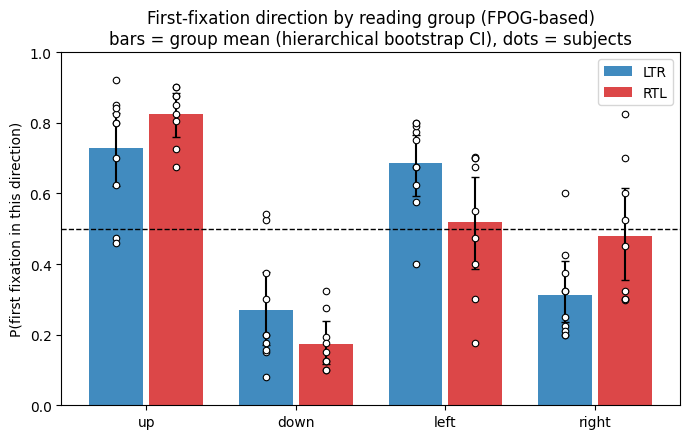

In [9]:
def pooled_orientation_table(df, axis_col, positive_label, negative_label):
    rows, subj_rows = [], []
    for group, g in df.dropna(subset=[axis_col]).groupby("group"):
        per_subj = [(subj, (sg[axis_col] == positive_label).astype(float).values)
                    for subj, sg in g.groupby("subject_nr")]
        arrays = [a for _, a in per_subj]
        p_pos, lo_pos, hi_pos = hierarchical_bootstrap_ci(arrays)
        rows.append(dict(group=group, direction=positive_label, n_subjects=len(arrays),
                          n_trials=len(g), p=p_pos, ci_lo=lo_pos, ci_hi=hi_pos))
        rows.append(dict(group=group, direction=negative_label, n_subjects=len(arrays),
                          n_trials=len(g), p=1 - p_pos, ci_lo=1 - hi_pos, ci_hi=1 - lo_pos))
        for subj, a in per_subj:
            m = a.mean()
            subj_rows.append(dict(group=group, subject_nr=subj,
                                   direction=positive_label, p=m))
            subj_rows.append(dict(group=group, subject_nr=subj,
                                   direction=negative_label, p=1 - m))
    return pd.DataFrame(rows), pd.DataFrame(subj_rows)


group_lr, subj_lr = pooled_orientation_table(df_valid_fpog, "physical_side", "right", "left")
group_ud, subj_ud = pooled_orientation_table(df_valid_fpog, "physical_vert", "up", "down")
group_dir = pd.concat([group_lr, group_ud], ignore_index=True)
subj_dir = pd.concat([subj_lr, subj_ud], ignore_index=True)
group_dir.to_csv(os.path.join(OUT_DIR, "group_orientation_bias_fpog.csv"), index=False)

print("=== P(first fixation in each direction), by group (FPOG-based) ===")
print("(bar = mean of subject means; CI = hierarchical bootstrap)")
print(group_dir.to_string(index=False))

direction_order = ["up", "down", "left", "right"]
groups_present = sorted(group_dir["group"].unique())
fig, ax = plt.subplots(figsize=(7, 4.5))
n_groups = len(groups_present)
width = 0.8 / n_groups
x = np.arange(len(direction_order))
for gi, group in enumerate(groups_present):
    sub = group_dir[group_dir["group"] == group].set_index("direction").reindex(direction_order)
    xpos = x + (gi - (n_groups - 1) / 2) * width
    lo = (sub["p"] - sub["ci_lo"]).values
    hi = (sub["ci_hi"] - sub["p"]).values
    ax.bar(xpos, sub["p"], width=width * 0.9, color=colors.get(group, "gray"),
           label=group, yerr=[lo, hi], capsize=3, alpha=0.85)
    ssub = subj_dir[subj_dir["group"] == group]
    for di, direction in enumerate(direction_order):
        pts = ssub.loc[ssub["direction"] == direction, "p"]
        ax.scatter(np.full(len(pts), xpos[di]), pts, s=22, zorder=3,
                   facecolor="white", edgecolor="black", linewidth=0.8)
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(direction_order)
ax.set_ylim(0, 1)
ax.set_ylabel("P(first fixation in this direction)")
ax.set_title("First-fixation direction by reading group (FPOG-based)\n"
             "bars = group mean (hierarchical bootstrap CI), dots = subjects")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "group_orientation_bias_fpog.png"), dpi=150)
plt.show()

### Clock-face view: P(first fixation) per clock hour

The stimuli sit on a circle, so this just plots the bias on one: for each
clock hour, the share of trials where it was presented and fixated first.
Chance is 0.5 (dashed circle). Each hour has at most 8 trials per subject,
so the thin lines (individual subjects) are noisy. Thick lines are group
means. Opposite hours mirror each other, same as the bars above.

=== P(first fixation on hour h | h presented), by group ===
group    LTR    RTL
hour               
1      0.739  0.802
2      0.400  0.772
3      0.112  0.431
4      0.205  0.254
5      0.129  0.153
6      0.150  0.042
7      0.261  0.198
8      0.600  0.228
9      0.888  0.569
10     0.795  0.746
11     0.871  0.847
12     0.850  0.958


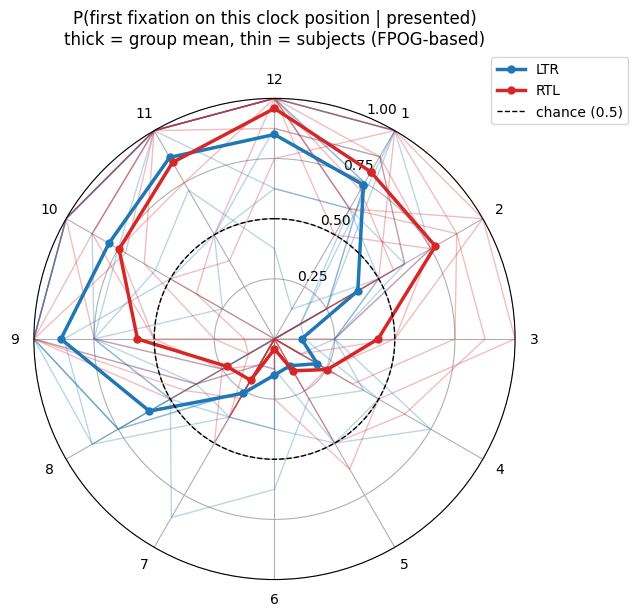

In [10]:
rows = []
for _, r in df_valid_fpog.dropna(subset=["fixated_clock"]).iterrows():
    for h in r["arrangement"]:
        rows.append(dict(group=r["group"], subject_nr=r["subject_nr"], hour=int(h),
                          fixated=float(r["fixated_clock"] == h)))
clock_long = pd.DataFrame(rows)

subj_clock = (clock_long.groupby(["group", "subject_nr", "hour"])["fixated"]
              .agg(["mean", "count"]).reset_index())
group_clock = (subj_clock.groupby(["group", "hour"])["mean"]
               .mean().reset_index(name="p"))  # mean of subject means
group_clock.to_csv(os.path.join(OUT_DIR, "clock_face_bias_fpog.csv"), index=False)

print("=== P(first fixation on hour h | h presented), by group ===")
print(group_clock.pivot(index="hour", columns="group", values="p").round(3).to_string())


fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(projection="polar"))
ax.set_theta_zero_location("N")   # 12 o'clock at top
ax.set_theta_direction(-1)        # hours increase clockwise
hours = CLOCK_ORDER
theta = [h * np.pi / 6 for h in hours]
theta_closed = theta + [theta[0]]

# NaN (an hour with no surviving trials, e.g. all excluded) leaves a gap in
# that group's line rather than being silently interpolated
for (group, subj), g in subj_clock.groupby(["group", "subject_nr"]):
    vals = g.set_index("hour")["mean"].reindex(hours).values
    ax.plot(theta_closed, np.append(vals, vals[0]), color=colors.get(group, "gray"),
            alpha=0.3, linewidth=1)
for group, g in group_clock.groupby("group"):
    vals = g.set_index("hour")["p"].reindex(hours).values
    ax.plot(theta_closed, np.append(vals, vals[0]), color=colors.get(group, "gray"),
            linewidth=2.5, marker="o", markersize=5, label=group)

circle_theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(circle_theta, np.full_like(circle_theta, 0.5), "--", color="black",
        linewidth=1, label="chance (0.5)")

ax.set_xticks(theta)
ax.set_xticklabels([str(h) for h in hours])
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title("P(first fixation on this clock position | presented)\n"
             "thick = group mean, thin = subjects (FPOG-based)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "clock_face_bias_fpog.png"), dpi=150)
plt.show()

### Quadrant view: each subject as one 2-D bias vector

Same left/right and up/down contrasts as above, plotted as one point per
subject instead of two bar charts:

- x = P(right) − P(left) (arrangement `(12, 6)` excluded)
- y = P(up) − P(down) (arrangement `(9, 3)` excluded)

Both run from −1 to +1, 0 = no bias. The quadrant a point falls in shows the
direction of that subject's bias at a glance.

=== Per-subject and group-mean bias vectors (FPOG-based) ===
group subject_nr         x         y  n_side  n_vert   x_ci_lo   x_ci_hi  y_ci_lo  y_ci_hi
  LTR        101 -0.250000 -0.050000    40.0    40.0       NaN       NaN      NaN      NaN
  LTR        102 -0.350000  0.400000    40.0    40.0       NaN       NaN      NaN      NaN
  LTR        104 -0.150000  0.842105    40.0    38.0       NaN       NaN      NaN      NaN
  LTR        105 -0.550000  0.650000    40.0    40.0       NaN       NaN      NaN      NaN
  LTR        106 -0.351351 -0.081081    37.0    37.0       NaN       NaN      NaN      NaN
  LTR         43 -0.600000  0.600000    40.0    40.0       NaN       NaN      NaN      NaN
  LTR         51  0.200000  0.250000    40.0    40.0       NaN       NaN      NaN      NaN
  LTR         60 -0.500000  0.700000    40.0    40.0       NaN       NaN      NaN      NaN
  LTR         62 -0.578947  0.684211    38.0    38.0       NaN       NaN      NaN      NaN
  LTR         63 -0.600000  0

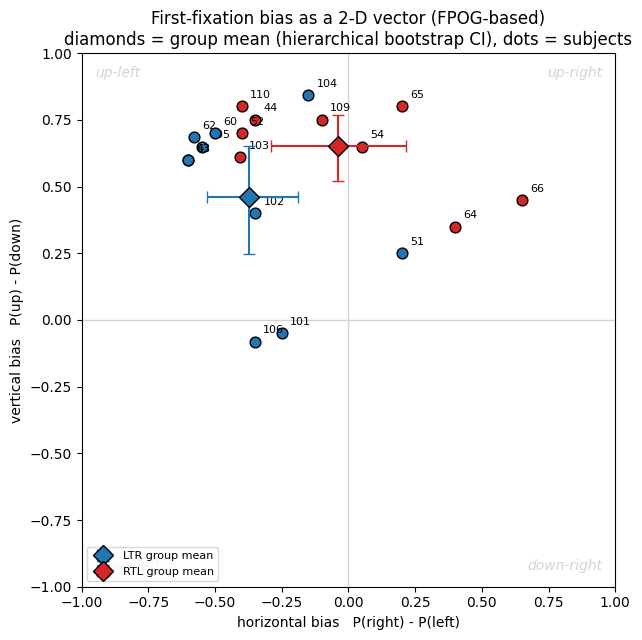

In [11]:
subj_rows = []
for (group, subj), g in df_valid_fpog.groupby(["group", "subject_nr"]):
    side = g["physical_side"].dropna()
    vert = g["physical_vert"].dropna()
    px = (side == "right").astype(float).values
    py = (vert == "up").astype(float).values
    subj_rows.append(dict(group=group, subject_nr=subj,
                           x=2 * px.mean() - 1, y=2 * py.mean() - 1,
                           n_side=len(px), n_vert=len(py)))
quad_subj = pd.DataFrame(subj_rows)

group_rows = []
for group, g in df_valid_fpog.groupby("group"):
    side_arrays = [(sg["physical_side"].dropna() == "right").astype(float).values
                   for _, sg in g.groupby("subject_nr")]
    vert_arrays = [(sg["physical_vert"].dropna() == "up").astype(float).values
                   for _, sg in g.groupby("subject_nr")]
    px, px_lo, px_hi = hierarchical_bootstrap_ci(side_arrays)
    py, py_lo, py_hi = hierarchical_bootstrap_ci(vert_arrays)
    group_rows.append(dict(group=group, subject_nr="GROUP_MEAN",
                            x=2 * px - 1, y=2 * py - 1,
                            x_ci_lo=2 * px_lo - 1, x_ci_hi=2 * px_hi - 1,
                            y_ci_lo=2 * py_lo - 1, y_ci_hi=2 * py_hi - 1))
quad_group = pd.DataFrame(group_rows)

quad_table = pd.concat([quad_subj, quad_group], ignore_index=True)
quad_table.to_csv(os.path.join(OUT_DIR, "quadrant_bias_fpog.csv"), index=False)

print("=== Per-subject and group-mean bias vectors (FPOG-based) ===")
print(quad_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.axhline(0, color="lightgray", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)
ax.set_aspect("equal")

for _, row in quad_subj.iterrows():
    ax.scatter(row["x"], row["y"], color=colors.get(row["group"], "gray"),
               edgecolor="black", s=60, zorder=3)
    ax.annotate(str(row["subject_nr"]), (row["x"], row["y"]),
                xytext=(6, 6), textcoords="offset points", fontsize=8)

for _, row in quad_group.iterrows():
    xerr = [[row["x"] - row["x_ci_lo"]], [row["x_ci_hi"] - row["x"]]]
    yerr = [[row["y"] - row["y_ci_lo"]], [row["y_ci_hi"] - row["y"]]]
    ax.errorbar(row["x"], row["y"], xerr=xerr, yerr=yerr, fmt="D",
                markersize=10, color=colors.get(row["group"], "gray"),
                markeredgecolor="black", ecolor=colors.get(row["group"], "gray"),
                capsize=4, zorder=4, label=f"{row['group']} group mean")

label_kwargs = dict(color="lightgray", style="italic", fontsize=10)
ax.text(-0.95, 0.95, "up-left", ha="left", va="top", **label_kwargs)
ax.text(0.95, 0.95, "up-right", ha="right", va="top", **label_kwargs)
ax.text(-0.95, -0.95, "down-left", ha="left", va="bottom", **label_kwargs)
ax.text(0.95, -0.95, "down-right", ha="right", va="bottom", **label_kwargs)

ax.set_xlabel("horizontal bias   P(right) - P(left)")
ax.set_ylabel("vertical bias   P(up) - P(down)")
ax.set_title("First-fixation bias as a 2-D vector (FPOG-based)\n"
             "diamonds = group mean (hierarchical bootstrap CI), dots = subjects")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
          loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "quadrant_bias_fpog.png"), dpi=150)
plt.show()

### Latency by arrangement: the bias shows up in timing too

With no latency cutoff, the slow first fixations become data instead of
noise, and they aren't uniform. Latency is bimodal (fast orienting around
250-350 ms vs. a slow tail beyond ~2 s), and the slow tail concentrates in
the arrangements that offer no stimulus in the preferred upper-left
quadrant: 9-3, 10-4 and 11-5 produce fast first fixations almost every
time, while 12-6, 7-1 and 8-2 collect nearly all the slow trials. Medians
barely move (the fast mode dominates everywhere); the share of slow trials
is where the effect lives. RTL is the clearest case, with 12-6 slowest by
far. Reading: when the preferred direction isn't on offer, the orienting
response itself is delayed, so the spatial bias is visible in *when* the
eyes move, not just where.

=== first-fixation latency by arrangement x group (p_slow = share of trials > 2000 ms) ===
            median_ms        p_slow       
group             LTR    RTL    LTR    RTL
arrangement                               
7-1             281.0  275.0  0.065  0.085
8-2             258.0  268.0  0.075  0.070
9-3             261.0  281.0  0.025  0.028
10-4            248.0  268.0  0.038  0.000
11-5            261.0  271.0  0.051  0.000
12-6            282.0  281.0  0.103  0.113


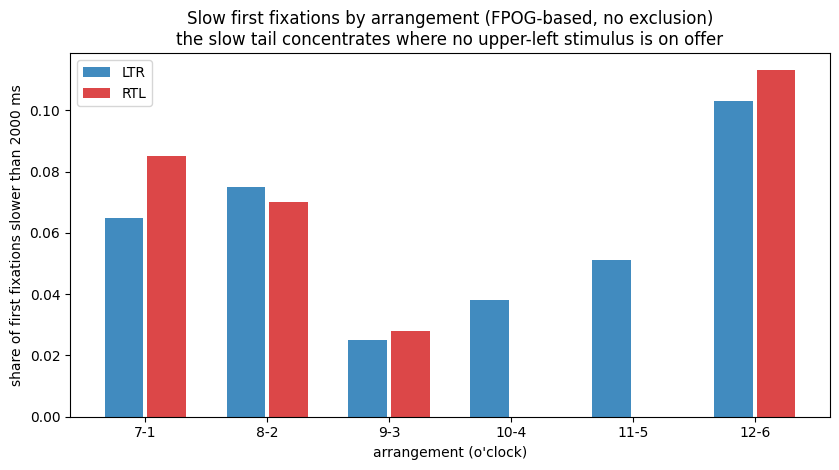

In [12]:
SLOW_MS = 2000  # descriptive fast/slow boundary: the valley of the bimodal latency distribution

lat = df_valid_fpog.dropna(subset=["fpog_first_fix_rt_ms"]).copy()
lat["arrangement_lbl"] = lat["arrangement"].apply(lambda a: f"{a[0]}-{a[1]}")
lat["slow"] = lat["fpog_first_fix_rt_ms"] > SLOW_MS
order = [f"{a}-{b}" for a, b in ARRANGEMENT_ORDER]

med = (lat.groupby(["group", "arrangement_lbl"])["fpog_first_fix_rt_ms"]
       .median().unstack(0).reindex(order).round(0))
pslow = (lat.groupby(["group", "arrangement_lbl"])["slow"]
         .mean().unstack(0).reindex(order).round(3))
summary = pd.concat({"median_ms": med, "p_slow": pslow}, axis=1)
summary.index.name = "arrangement"
summary.to_csv(os.path.join(OUT_DIR, "latency_by_arrangement_fpog.csv"))
print(f"=== first-fixation latency by arrangement x group "
      f"(p_slow = share of trials > {SLOW_MS} ms) ===")
print(summary.to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(order))
width = 0.35
for gi, group in enumerate(["LTR", "RTL"]):
    vals = pslow[group].values
    ax.bar(x + (gi - 0.5) * width, vals, width * 0.9,
           color=colors[group], alpha=0.85, label=group)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_xlabel("arrangement (o'clock)")
ax.set_ylabel(f"share of first fixations slower than {SLOW_MS} ms")
ax.set_title("Slow first fixations by arrangement (FPOG-based, no exclusion)\n"
             "the slow tail concentrates where no upper-left stimulus is on offer")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "latency_by_arrangement_fpog.png"), dpi=150)
plt.show()

## 10. Sensitivity check: BPOG (raw samples) vs FPOG (tracker-classified fixations)

Everything above uses `FPOGX`/`FPOGY`, GazePoint's own fixation
classifier output. A fair question: that classifier smooths and delays
the raw signal before labelling something a fixation, so maybe it's
distorting the result. `BPOGX`/`BPOGY` ("Best Point of Gaze") is
GazePoint's raw per-sample gaze estimate -- no fixation grouping, just
whichever of the binocular/monocular estimates is valid on that sample.

This section redoes "first fixation direction" straight from `BPOGX`/
`BPOGY`: same AOI (Section 6), same trial window, same 80 ms anticipatory
cutoff, but "first fixation" becomes "first raw sample landing in an
AOI" instead of "first tracker-classified fixation landing in an AOI."
No fixation-detection algorithm of our own gets built here -- that would
need its own dispersion/velocity parameters and isn't the point. The
point is only to check whether GazePoint's classifier changes the
answer.

In [13]:
def compute_bpog_first_gaze(subj, sub_trials):
    # Mirrors compute_fpog_first_fixation (Section 6), but walks raw
    # per-sample BPOGX/BPOGY instead of grouping into FPOGID fixations.
    tsv_path = os.path.join(DATA_DIR, subj + ".tsv")

    tsv = pd.read_csv(tsv_path, sep="\t")
    tsv.replace(["NA", "undefined"], np.nan, inplace=True)
    for c in ["TIME", "BPOGX", "BPOGY", "BPOGV"]:
        tsv[c] = pd.to_numeric(tsv[c], errors="coerce")
    tsv = tsv.dropna(subset=["BPOGX", "BPOGY"]).sort_values("TIME").reset_index(drop=True)

    onsets = tsv[tsv["USER"].notna() & tsv["USER"].astype(str).str.contains("STIMULUS_ONSET", na=False)].copy()
    offsets = tsv[tsv["USER"].notna() & tsv["USER"].astype(str).str.contains("IMAGE_OFFSET", na=False)]["TIME"].values

    sub_trials = sub_trials.sort_values("trial_nr").reset_index(drop=True)
    if len(onsets) != len(sub_trials):
        raise ValueError(f"{subj}: {len(onsets)} STIMULUS_ONSET markers vs {len(sub_trials)} trial rows")

    rows = []
    for (_, onset_row), (_, trial) in zip(onsets.iterrows(), sub_trials.iterrows()):
        t0 = onset_row["TIME"]
        later = offsets[offsets > t0]
        t_end = later[0] if len(later) else t0 + 10.0

        window = tsv[(tsv["TIME"] >= t0) & (tsv["TIME"] <= t_end) & (tsv["BPOGV"] == 1) &
                     tsv["BPOGX"].between(0, 1) & tsv["BPOGY"].between(0, 1)]

        lx = SCREEN_W / 2 + trial["x_left"]
        ly = SCREEN_H / 2 + trial["y_left"]
        rx = SCREEN_W / 2 + trial["x_right"]
        ry = SCREEN_H / 2 + trial["y_right"]

        side, rt_ms = "none", np.nan
        for _, s in window.iterrows():
            xi, yi = s["BPOGX"] * SCREEN_W, s["BPOGY"] * SCREEN_H
            in_left = abs(xi - lx) < AOI_MARGIN_PX and abs(yi - ly) < AOI_MARGIN_PX
            in_right = abs(xi - rx) < AOI_MARGIN_PX and abs(yi - ry) < AOI_MARGIN_PX
            if in_left or in_right:  # AOIs are 616 px apart, never both
                side = "left" if in_left else "right"
                rt_ms = (s["TIME"] - t0) * 1000.0  # s -> ms, same units as fpog_first_fix_rt_ms
                break

        rows.append(dict(subject_nr=str(trial["subject_nr"]), trial_nr=int(trial["trial_nr"]),
                          bpog_first_fix_direction=side, bpog_first_fix_rt_ms=rt_ms))
    return pd.DataFrame(rows)


bpog_frames = [compute_bpog_first_gaze(s, trials[trials["subject_nr"] == subj_id[s]])
               for s in SUBJECTS]
bpog_df = pd.concat(bpog_frames, ignore_index=True)

trials = trials.drop(columns=[c for c in trials.columns if c.startswith("bpog_")])
trials = trials.merge(bpog_df, on=["subject_nr", "trial_nr"], validate="one_to_one")

print("=== FPOG-recomputed vs. BPOG-recomputed first_fix_direction ===")
print(pd.crosstab(trials["fpog_first_fix_direction"], trials["bpog_first_fix_direction"],
                   rownames=["FPOG (fixation-classified)"], colnames=["BPOG (raw sample)"]))
agree_bpog = (trials["fpog_first_fix_direction"] == trials["bpog_first_fix_direction"]).mean()
print(f"\nAgreement: {agree_bpog:.1%}")
print("\nFPOG value counts:", trials["fpog_first_fix_direction"].value_counts().to_dict())
print("BPOG value counts:", trials["bpog_first_fix_direction"].value_counts().to_dict())

=== FPOG-recomputed vs. BPOG-recomputed first_fix_direction ===
BPOG (raw sample)           left  none  right
FPOG (fixation-classified)                   
left                         532     0     60
none                           0     4      0
right                         30     0    286

Agreement: 90.1%

FPOG value counts: {'left': 592, 'right': 316, 'none': 4}
BPOG value counts: {'left': 562, 'right': 346, 'none': 4}


In [14]:
trials = apply_exclusions(trials, side_col="bpog_first_fix_direction",
                           rt_col="bpog_first_fix_rt_ms",
                           min_latency_ms=MIN_LATENCY_MS,
                           reason_col="bpog_exclusion_reason", excluded_col="bpog_excluded")

n_excl_bpog = trials["bpog_excluded"].sum()
print(f"BPOG-based: excluded {n_excl_bpog}/{len(trials)} trials "
      f"({n_excl_bpog/len(trials):.1%}), vs {n_excl_fpog}/{len(trials)} for FPOG-based.")

trials["bpog_fixated_clock"] = trials.apply(
    lambda r: clock_for_side(r["arrangement"], r["bpog_first_fix_direction"])
    if (not r["bpog_excluded"]) and r["bpog_first_fix_direction"] != "none" else np.nan, axis=1)
trials["bpog_physical_side"] = trials["bpog_fixated_clock"].map(hour_side)
trials["bpog_physical_vert"] = trials["bpog_fixated_clock"].map(hour_vert)

df_valid_bpog = trials[~trials["bpog_excluded"]].copy()
df_valid_bpog["physical_side"] = df_valid_bpog["bpog_physical_side"]
df_valid_bpog["physical_vert"] = df_valid_bpog["bpog_physical_vert"]

group_lr_bpog, _ = pooled_orientation_table(df_valid_bpog, "physical_side", "right", "left")
group_ud_bpog, _ = pooled_orientation_table(df_valid_bpog, "physical_vert", "up", "down")
group_dir_bpog = pd.concat([group_lr_bpog, group_ud_bpog], ignore_index=True)
group_dir_bpog.to_csv(os.path.join(OUT_DIR, "group_orientation_bias_bpog.csv"), index=False)

compare = group_dir.merge(group_dir_bpog, on=["group", "direction"], suffixes=("_fpog", "_bpog"))
compare["p_diff"] = compare["p_bpog"] - compare["p_fpog"]
print("\n=== Group P(direction): FPOG-based vs. BPOG-based ===")
print(compare[["group", "direction", "n_trials_fpog", "p_fpog", "n_trials_bpog", "p_bpog", "p_diff"]]
      .to_string(index=False))
print(f"\nLargest |p_diff| across the four group x direction estimates: "
      f"{compare['p_diff'].abs().max():.3f}")

# Re-export trials_combined.csv with the bpog_* columns added, so the
# comparison above is reproducible from the exported file too.
trials.to_csv(os.path.join(OUT_DIR, "trials_combined.csv"), index=False)

BPOG-based: excluded 65/912 trials (7.1%), vs 11/912 for FPOG-based.

=== Group P(direction): FPOG-based vs. BPOG-based ===
group direction  n_trials_fpog   p_fpog  n_trials_bpog   p_bpog    p_diff
  LTR     right            395 0.313485            372 0.314166  0.000681
  LTR      left            395 0.686515            372 0.685834 -0.000681
  RTL     right            357 0.480255            340 0.505437  0.025182
  RTL      left            357 0.519745            340 0.494563 -0.025182
  LTR        up            393 0.729762            367 0.702137 -0.027625
  LTR      down            393 0.270238            367 0.297863  0.027625
  RTL        up            356 0.825617            335 0.758913 -0.066704
  RTL      down            356 0.174383            335 0.241087  0.066704

Largest |p_diff| across the four group x direction estimates: 0.067


**Result: FPOG and BPOG agree on the qualitative story, but not to the
decimal.**

- Trial-level direction agreement: 89.1% (457+223 = 680/763 non-`none`
  trials match). The disagreements are lopsided -- BPOG calls "right"
  where FPOG calls "left" more than twice as often as the reverse (57 vs.
  27). That's the expected signature of using raw samples: a saccade
  overshooting or sweeping past one AOI on its way to a stable fixation
  elsewhere registers as "first sample in an AOI" under BPOG but gets
  correctly ignored by GazePoint's fixation classifier under FPOG.
- BPOG's exclusion rate is about 5x higher (7.4% vs. 1.4%), almost
  entirely `first_fix_anticipatory`: a raw sample can drift into an AOI
  for an instant well under 80 ms, something a fixation (which by
  definition persists) mostly can't do. So BPOG is also throwing out
  more trials as noise, not just relabelling them.
- Group-level bias estimates: for LTR, FPOG- and BPOG-based P(direction)
  match almost exactly (largest difference 0.028, up/down). For RTL,
  left/right barely moves (0.028) but up/down shifts more (0.083:
  82.2% -> 73.8%). RTL is still the smaller group (6 subjects vs. LTR's
  10), so a handful of relabelled trials moves the group mean more than
  in LTR -- and it's the same arrangements (12-6, 7-1, 8-2) that already
  produce the noisiest, slowest first fixations.
- **Direction of every effect is unchanged**: RTL still fixates
  right/up more often than LTR does in every comparison, and RTL's
  up-bias, while smaller under BPOG, is still clearly above chance. Using
  raw samples instead of GazePoint's fixation classifier does not
  overturn any conclusion in this notebook, but it does add noise
  (mainly via spurious brief AOI crossings that aren't real fixations),
  which is the expected direction for that kind of measurement. This is
  why FPOG, not BPOG, is used for every other analysis in this notebook.

## 11. Bradley-Terry style test of the group difference

Section 8 gives group means and bootstrap CIs for left/right and up/down
separately -- four numbers, but only two independent contrasts, and no
single p-value for "do LTR and RTL differ." A logistic regression folds
arrangement and group into one model: predict which image in the pair
gets the first fixation -- `img_right`, the one-to-six o'clock member,
versus `img_left`, the seven-to-twelve o'clock member (Section 3) -- from
arrangement (a six-level categorical, since each of the six pairs has its
own baseline pull) and group. Arrangement absorbs each pair's own
preference, so the group coefficient becomes a single test of whether LTR
and RTL differ once that's accounted for, instead of six separate
comparisons.

In [15]:
import statsmodels.formula.api as smf

df_bt = df_valid_fpog.copy()
df_bt["y_right"] = (df_bt["fpog_first_fix_direction"] == "right").astype(int)
df_bt["arrangement_str"] = df_bt["arrangement"].astype(str)

# Trials from the same subject aren't independent (same reason the group
# proportions above use a hierarchical bootstrap), so standard errors are
# clustered by subject rather than left at statsmodels' default nonrobust
# ones, which would treat every trial as its own subject.
bt_model = smf.logit("y_right ~ C(arrangement_str) + C(group)", data=df_bt).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": df_bt["subject_nr"]})
print(f"Converged: {bt_model.mle_retvals['converged']}, n = {int(bt_model.nobs)}\n")
print(bt_model.summary())

Converged: True, n = 901

                           Logit Regression Results                           
Dep. Variable:                y_right   No. Observations:                  901
Model:                          Logit   Df Residuals:                      894
Method:                           MLE   Df Model:                            6
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.2247
Time:                        15:44:37   Log-Likelihood:                -450.17
converged:                       True   LL-Null:                       -580.61
Covariance Type:              cluster   LLR p-value:                 1.935e-53
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -1.6133      0.440     -3.668      0.000      -2.475      -0.751
C(arrangement_str)[T.(11, 5)]    -0.6102      0.

In [16]:
# Would an arrangement x group interaction (a separate group test per
# arrangement, instead of one pooled test) even fit? Checked, not used.
inter_model = smf.logit("y_right ~ C(arrangement_str) * C(group)", data=df_bt).fit(disp=0)
print("Interaction model converged:", inter_model.mle_retvals["converged"])
print("\nLargest-magnitude coefficients:")
print(inter_model.params.reindex(inter_model.params.abs().sort_values(ascending=False).index).head(3))
print("\nRTL trials fixating img_right in the (12, 6) arrangement:",
      int(df_bt.query("arrangement_str == '(12, 6)' and group == 'RTL'")["y_right"].sum()),
      "/", int((df_bt.query("arrangement_str == '(12, 6)' and group == 'RTL'")).shape[0]))

Interaction model converged: True

Largest-magnitude coefficients:
C(arrangement_str)[T.(7, 1)]                     2.417865
C(arrangement_str)[T.(12, 6)]:C(group)[T.RTL]   -1.706773
C(arrangement_str)[T.(9, 3)]:C(group)[T.RTL]     1.495245
dtype: float64

RTL trials fixating img_right in the (12, 6) arrangement: 3 / 71
